In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. DATA LOADING
---

In [40]:
#Load data
#Try to load data from Kaggle input directory, if not found, load from local directory
try:
    print("Loading data from Kaggle input directory...")
    train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
    test_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
    sample_submission_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv')
    print("Data loaded successfully from Kaggle input directory.")
except FileNotFoundError as e:
    data_path = os.getcwd() + "\\playground_series\\data"
    print("Data not found in Kaggle input directory. Loading from local directory...")
    train_df = pd.read_csv(data_path + "\\train.csv")
    test_df = pd.read_csv(data_path + "\\test.csv")
    sample_submission_df = pd.read_csv(data_path + "\\sample_submission.csv")
    print("Data loaded successfully from local directory.")

Loading data from Kaggle input directory...
Data not found in Kaggle input directory. Loading from local directory...
Data loaded successfully from local directory.


# 2. DATA EXPLORATION
---

Exploring the data to check for:
* Missing values.
* Mislabled data types.
* Class Imbalance.
* Outlier values.




In [41]:
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [42]:
train_df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [43]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

In [44]:
def summarize_dataframe(df):
    '''Breakdown of dataframe structure, missing values, and duplicates'''
    print("----------------------------------------------------------")
    print("DataFrame Summary:")
    print(f'Number of rows: {df.shape[0]}')
    print(f'Number of columns: {df.shape[1]}')
    print(f'The total number of missing values in the dataset is: {df.isnull().sum().sum()}')
    print(f'The total number of duplicate rows in the dataset is: {df.duplicated().sum()}')
    print(f'The number of numeric columns: {df.select_dtypes(include=[np.number]).shape[1]}')
    print(f'The number of categorical columns: {df.select_dtypes(include=[str]).shape[1]}')
    print("----------------------------------------------------------\n")
    

In [45]:
summarize_dataframe(train_df)
summarize_dataframe(test_df)

----------------------------------------------------------
DataFrame Summary:
Number of rows: 630000
Number of columns: 21
The total number of missing values in the dataset is: 0
The total number of duplicate rows in the dataset is: 0
The number of numeric columns: 12
The number of categorical columns: 9
----------------------------------------------------------

----------------------------------------------------------
DataFrame Summary:
Number of rows: 270000
Number of columns: 20
The total number of missing values in the dataset is: 0
The total number of duplicate rows in the dataset is: 0
The number of numeric columns: 12
The number of categorical columns: 8
----------------------------------------------------------



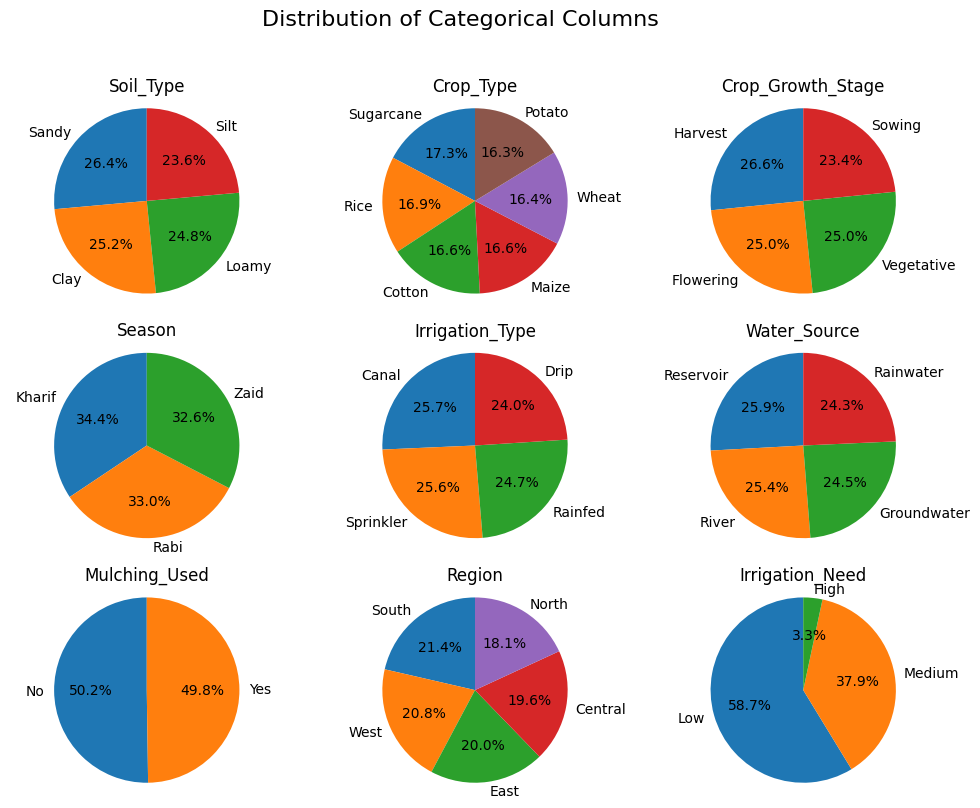

In [72]:
def plot_distribution_pie(df):

    '''Plot distribution of a categorical column as a pie chart with percentage labels in a grid layout'''
    #Creat a grid layout for multiple pie charts
    total_plots = len(df.select_dtypes(include=[str]).columns)

    if total_plots == 0:
        print("No categorical columns to plot.")
        return
    
    if total_plots%4 == 0:
        col = 4
    else:        
        col = 3

    row = math.ceil(total_plots/col)
    
    fig, axs = plt.subplots(nrows=row, ncols=col, figsize=(12, 3*row))
    fig.suptitle('Distribution of Categorical Columns', fontsize=16)

    if total_plots == 1:
        axs = [axs]
    else:
        axs = axs.flatten()
    
    for i, column in enumerate(df.select_dtypes(include=[str]).columns):
        value_counts = df[column].value_counts()
        labels = value_counts.index
        sizes = value_counts.values
        
        axs[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        axs[i].axis('equal')
        axs[i].set_title(column)

    for j in range(total_plots, len(axs)):
        axs[j].set_visible(False)

    plt.show()

plot_distribution_pie(train_df)

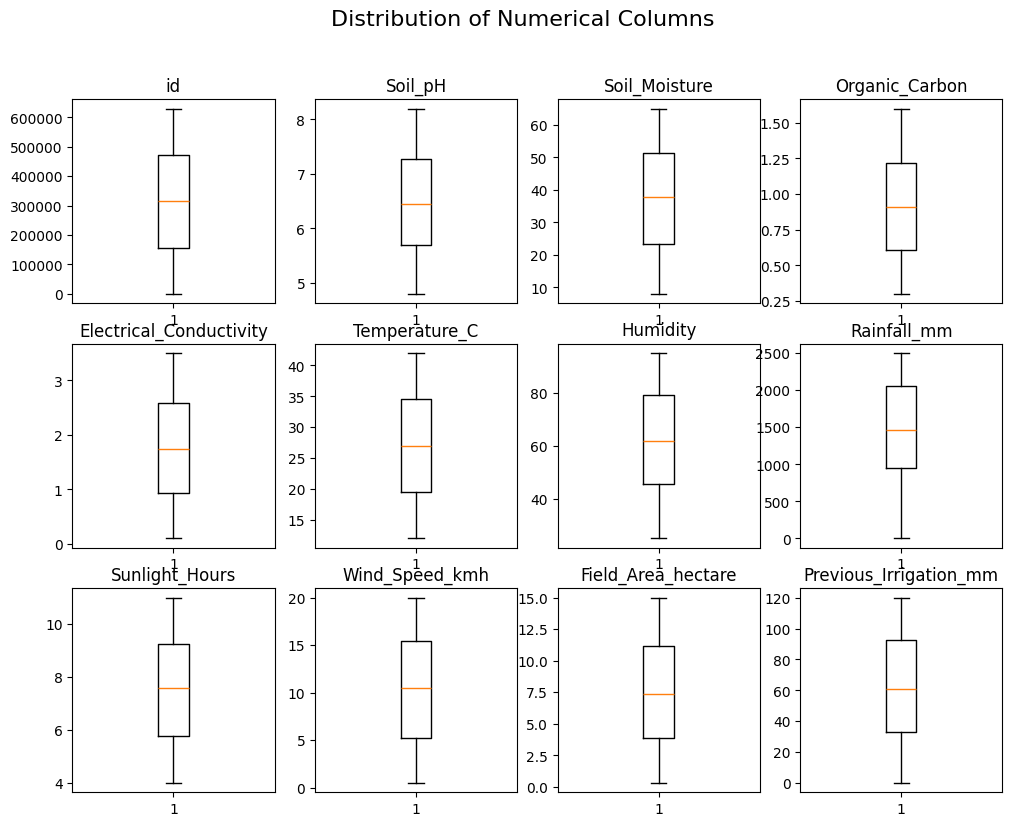

In [75]:
def plot_distribution_boxplot(df):

    '''Plot distribution of a categorical column as a box plot'''
    # Create a grid layout for multiple box plots
    total_plots = len(df.select_dtypes(include=[float, int]).columns)

    if total_plots == 0:
        print("No numerical columns to plot.")
        return
    
    if total_plots%4 == 0:
        col = 4
    else:        
        col = 3

    row = math.ceil(total_plots/col)
    
    fig, axs = plt.subplots(nrows=row, ncols=col, figsize=(12, 3*row))
    fig.suptitle('Distribution of Numerical Columns', fontsize=16)

    if total_plots == 1:
        axs = [axs]
    else:
        axs = axs.flatten()
    
    for i, column in enumerate(df.select_dtypes(include=[float, int]).columns):
        axs[i].boxplot(df[column])
        axs[i].set_title(column)
        

    for j in range(total_plots, len(axs)):
        axs[j].set_visible(False)

    plt.show()

plot_distribution_boxplot(train_df)

# 3. Data Preprocessing
---
Data exploration reveals the following that will need to be addressed:
* **Class Imbalance**: `Irrigation need` target variable is imbalance; High 3.3% , Medium 37.9% and Low 58.7%
* **Different value scales**: The box plots shows that while the numerical fields have a fairly even distribution each field has different maxes and minimums.

## Strategy
- Drop `id` column/field/feature as it has no influence on irrigation need.
- Add weights to counter the class imbalance.
- Normalize the data to ensure each column/field is treated equally.
- Encoding categorical fields for easy processing by machine learning models.


In [80]:
def clean_dataframe(df):
    '''Clean dataframe by dropping id column, normalizing numerical columns between 0 and 1, and encoding categorical columns using one-hot encoding for column with 2 unique values to either 0 or 1 and mapping for columns with more than 2 unique values from 1 to n unique values'''
    # Drop the id column
    df = df.drop(columns=['id'])

    # Normalize numerical columns
    numerical_columns = df.select_dtypes(include=[float, int]).columns
    for column in numerical_columns:
        df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())

    # Encode categorical columns
    categorical_columns = df.select_dtypes(include=[str]).columns
    for column in categorical_columns:
        if df[column].nunique() == 2:
            # One-hot encode columns with 2 unique values to either 0 or 1
            df[column] = df[column].map({df[column].unique()[0]: 0, df[column].unique()[1]: 1})
        else:
            # Map columns with more than 2 unique values from 1 to n unique values
            unique_values = df[column].unique()
            value_to_code = {value: code for code, value in enumerate(unique_values, start=1)}
            df[column] = df[column].map(value_to_code)

    return df

train_df_cleaned = clean_dataframe(train_df)

In [81]:
train_df_cleaned.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,1,0.035294,0.431304,0.546154,0.867647,0.100333,0.365909,0.290324,0.271429,0.835385,1,1,1,1,1,0.035374,0,0.934734,1,1
1,2,0.670588,0.852957,0.107692,0.558824,0.364000,0.612373,0.394221,0.425714,0.148205,2,2,2,2,2,0.338095,1,0.392932,2,1
2,2,0.261765,0.345850,0.392308,0.802941,0.499000,0.960423,0.880771,0.292857,0.171795,3,2,2,3,3,0.540136,1,0.919897,3,1
3,3,0.250000,0.093350,0.792308,0.226471,0.044000,0.522503,0.542930,0.731429,0.092821,2,3,2,4,2,0.545578,1,0.448696,2,2
4,2,0.929412,0.897350,0.061538,0.252941,0.274000,0.944564,0.615298,0.421429,0.689231,2,1,3,4,2,0.480952,0,0.776611,2,1
